Загрузите файл housing.csv


Saving housing.csv to housing (1).csv
Размер данных: (20640, 10)
Столбцы: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
Дубликатов: 0
Число признаков после предобработки: 12


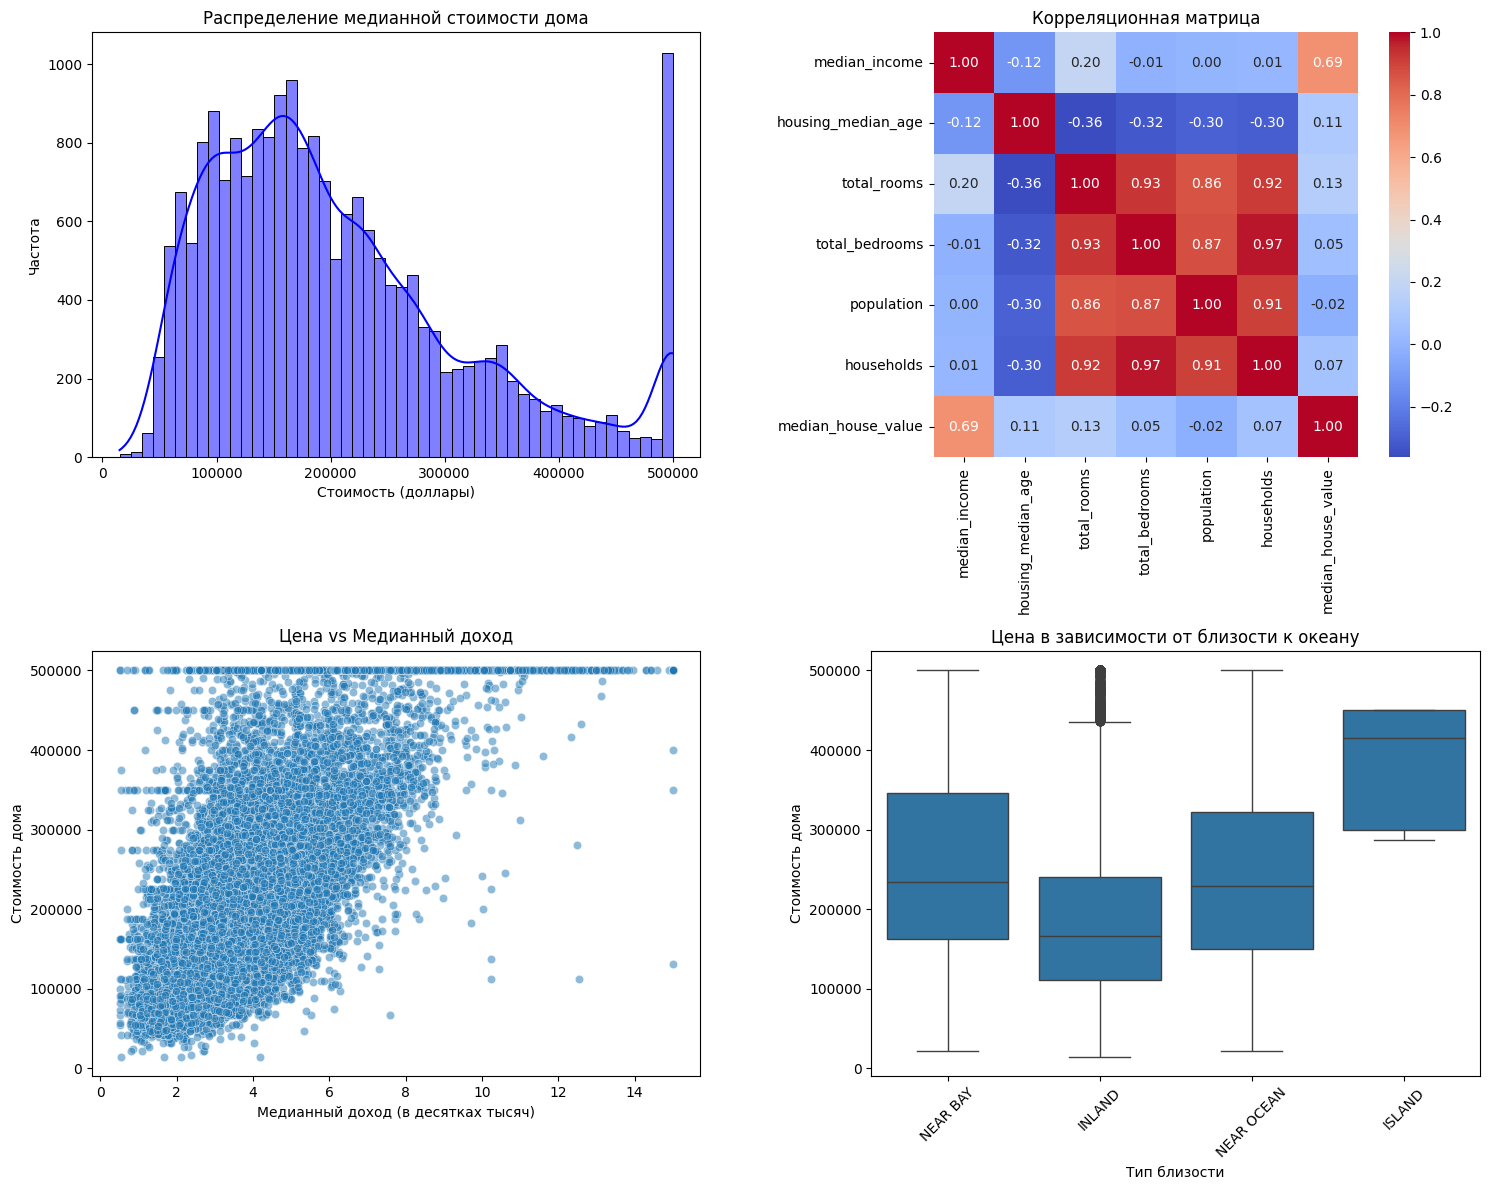

Train size: (16512, 12) Test size: (4128, 12)
Linear Regression    | MAE: 50670.7382 | RMSE: 70060.5218 | R2: 0.6254
Ridge Regression     | MAE: 50678.3586 | RMSE: 70068.8089 | R2: 0.6253
Random Forest        | MAE: 31642.7575 | RMSE: 49034.5748 | R2: 0.8165
Gradient Boosting    | MAE: 38248.0320 | RMSE: 55884.6590 | R2: 0.7617

Кросс-валидация (RMSE):
Linear Regression    | mean RMSE: 68604.1630 (+/- 1324.9472)
Ridge Regression     | mean RMSE: 68594.8658 (+/- 1315.3205)
Random Forest        | mean RMSE: 49326.6301 (+/- 1185.0073)
Gradient Boosting    | mean RMSE: 55102.0113 (+/- 1235.9585)


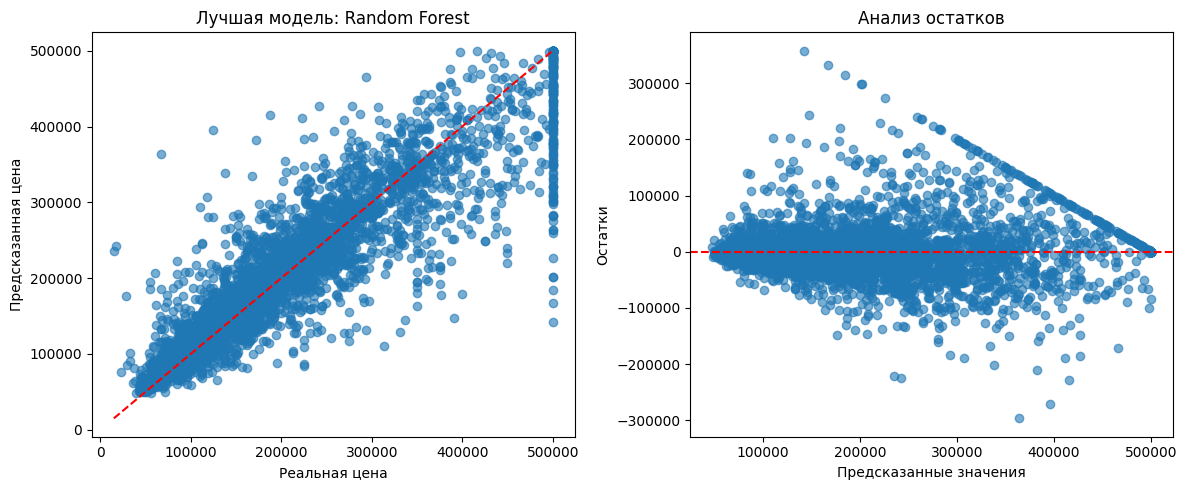

ИТОГИ

Лучшая модель по RMSE: Random Forest
RMSE: 49034.5748
R² : 0.8165


In [3]:

# 1. Импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


# 2. Загрузка данных

print("Загрузите файл housing.csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Размер данных:", df.shape)
print("Столбцы:", df.columns.tolist())


# 3. Предобработка


# 3.1. Пропуски в total_bedrooms – заполняем медианой
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# 3.2. Дубликаты
print("Дубликатов:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# 3.3. Категориальный признак ocean_proximity – бинарный
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# 3.4. Целевая переменная
y = df['median_house_value']
X = df.drop(columns=['median_house_value'])

# 3.5. Масштабирование числовых признаков (кроме бинарного)
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("Число признаков после предобработки:", X.shape[1])


# 4. EDA (графики)

plt.figure(figsize=(15, 12))

# 4.1. Распределение целевой переменной
plt.subplot(2, 2, 1)
sns.histplot(y, bins=50, kde=True, color='blue')
plt.title('Распределение медианной стоимости дома')
plt.xlabel('Стоимость (доллары)')
plt.ylabel('Частота')

# 4.2. Корреляционная матрица основных признаков
plt.subplot(2, 2, 2)
cols_for_corr = ['median_income', 'housing_median_age', 'total_rooms',
                 'total_bedrooms', 'population', 'households', 'median_house_value']
corr = df[cols_for_corr].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Корреляционная матрица')

# 4.3. Зависимость цены от дохода
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.5)
plt.title('Цена vs Медианный доход')
plt.xlabel('Медианный доход (в десятках тысяч)')
plt.ylabel('Стоимость дома')

# 4.4. Средняя цена по типу близости к океану
plt.subplot(2, 2, 4)
ocean_cols = [c for c in df.columns if c.startswith('ocean_proximity_')]
df['ocean_type'] = df[ocean_cols].idxmax(axis=1).str.replace('ocean_proximity_', '')
sns.boxplot(data=df, x='ocean_type', y='median_house_value')
plt.xticks(rotation=45)
plt.title('Цена в зависимости от близости к океану')
plt.xlabel('Тип близости')
plt.ylabel('Стоимость дома')

plt.tight_layout()
plt.show()


# 5. Разбиение на train/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "Test size:", X_test.shape)


# 6. Обучение моделей

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name:20} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")


# 7. Кросс-валидация

print("\nКросс-валидация (RMSE):")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    neg_mse = cross_val_score(model, X_train, y_train, cv=kf,
                              scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-neg_mse)
    print(f"{name:20} | mean RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")


# 8. График для лучшей модели

best_name = min(results, key=lambda x: results[x]['RMSE'])
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title(f'Лучшая модель: {best_name}')

plt.subplot(1,2,2)
residuals = y_test - y_pred_best
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Анализ остатков')
plt.tight_layout()
plt.show()


# 9. Выводы



print("ИТОГИ\n")

print(f"Лучшая модель по RMSE: {best_name}")
print(f"RMSE: {results[best_name]['RMSE']:.4f}")
print(f"R² : {results[best_name]['R2']:.4f}")